# Setup

In [ ]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from thesis_assyrian_relief.utils.config import load_yaml_config
from sklearn.model_selection import train_test_split



def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "pyproject.toml").is_file():
            return d
    return here


paths_yaml = _repo_root() / "configs" / "style_dinov2.yaml"
config = load_yaml_config(paths_yaml)

dataset_xlsx = config["data"]["dataset_xlsx"]
image_root = Path(config["data"]["image_root"])
RANDOM_SEED = config["random_seed"]

In [3]:
df_full = pd.read_excel(dataset_xlsx)

df_full["Authority"] = df_full["Authority"].str.strip().str.replace('\xa0', '', regex=False)

df_full.head()

,URL,Relief_ID,Museum,Authority,Grayscale,style_analysis_use,background_masking,Tier,Code,Contains_inscription,...,facade,Panels,Materials,Weight,Height,Width,Thickness,Curators_Comments,Inscription_translation,Unnamed: 29
0,https://www.metmuseum.org/art/collection/searc...,MET 31.72.2,Metropolitan,Ashurnasirpal II,NaN,core_train,NaN,B,NaN,1.0,...,NaN,NaN,Gypsum alabaster,NaN,233.7 cm,167.6 cm,6.4 cm,NaN,NaN,NaN
1,https://www.britishmuseum.org/collection/objec...,BM 118810,BM,Sargon II,1.0,core_train,1.0,A,NaN,0.0,...,NaN,NaN,limestone,NaN,8 inch,NaN,NaN,NaN,NaN,NaN
2,https://www.britishmuseum.org/collection/objec...,BM 118811,BM,Sargon II,1.0,extended_train,1.0,B,NaN,0.0,...,NaN,NaN,stone,NaN,25 inch,20 inch,NaN,NaN,NaN,NaN
3,https://www.britishmuseum.org/collection/objec...,BM 118820,BM,Sargon II,1.0,extended_train,1.0,A,NaN,0.0,...,NaN,NaN,stone,NaN,2 feet,19 inch,NaN,NaN,NaN,NaN
4,https://www.britishmuseum.org/collection/objec...,BM 118822,BM,Sargon II,0.0,core_train,1.0,B,NaN,0.0,...,NaN,NaN,gypsum,NaN,290 cm,230 cm,NaN,A duplicate of this scene was found in the pal...,NaN,NaN


# Select dataset use

dataset size: (242, 30)
unique reliefs in the dataset: 222
unique reliefs per authority:
                      Relief_ID
Authority                     
Ashurnasirpal II            77
Ashurbanipal                52
Sargon II                   50
Sennacherib                 25
Tiglath-Pileser III         18


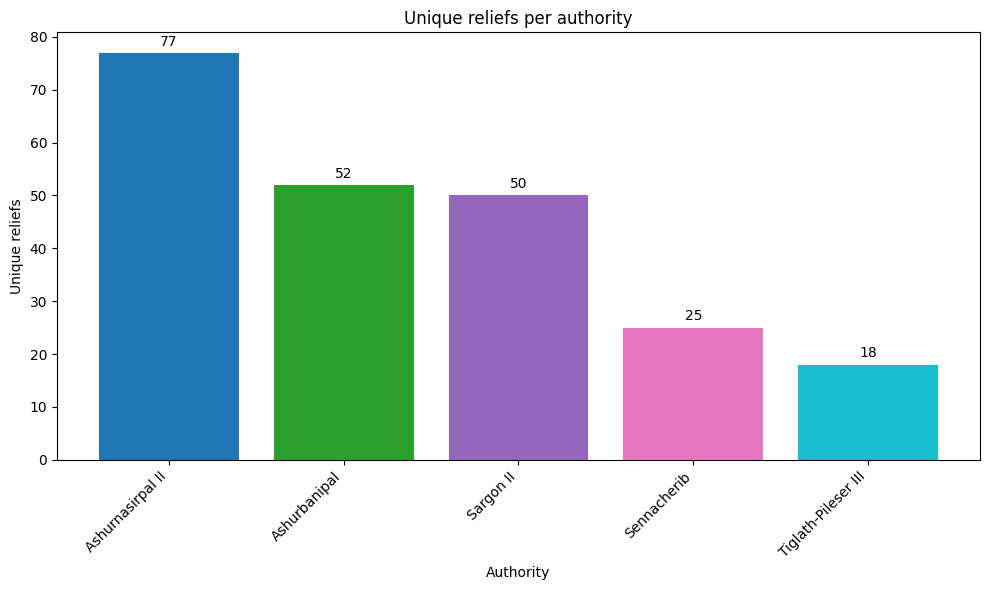

In [60]:
train = config["data"]["dataset_type"]
df = df_full.query("style_analysis_use == @train")
print(f"dataset size: {df.shape}")
print(f"unique reliefs in the dataset: {df['Relief_ID'].nunique()}")
assert df["Relief_ID"].notna().all(), "There are missing Relief_IDs."

# Each Relief_ID should belong to exactly one Authority
relief_authority_counts = df.groupby("Relief_ID")["Authority"].nunique()
bad = relief_authority_counts[relief_authority_counts > 1]
assert bad.empty, f"Some Relief_IDs have multiple authorities:\n{bad}"

unique_reliefs_per_authority = df[['Authority', 'Relief_ID']].groupby(df['Authority']).nunique()
print(f"unique reliefs per authority:\n {unique_reliefs_per_authority.sort_values(by='Relief_ID', ascending=False)}")
assert unique_reliefs_per_authority.sum().values == df['Relief_ID'].nunique(), "There are duplicate Relief_IDs in the dataset."

counts = unique_reliefs_per_authority["Relief_ID"].sort_values(ascending=False)
n = len(counts)
colors = plt.cm.tab10(np.linspace(0, 0.9, n))
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(counts.index.astype(str), counts.values, color=colors)
ax.bar_label(bars, fmt="%d", padding=3, fontsize=10)
ax.set_xlabel("Authority")
ax.set_ylabel("Unique reliefs")
ax.set_title("Unique reliefs per authority")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=45, ha="right")
fig.tight_layout()
plt.show()


## background masking %

In [62]:
pd.crosstab(df["Authority"], df["background_masking"], normalize="index")

background_masking,0.0,1.0
Authority,,
Sargon II,0.603774,0.396226
Sennacherib,0.600000,0.400000
Tiglath-Pileser III,0.500000,0.500000


# Convert infrequent to OTHER

In [4]:
infrequent_cats = ['Sennacherib', 'Tiglath-Pileser III', 'Shalmaneser III']
df.loc[df['Authority'].isin(infrequent_cats), 'Authority'] = 'OTHER'

# split IDs

In [23]:
train_size = config["splits"]["train_size"]
val_size = config["splits"]["val_size"]
test_size = config["splits"]["test_size"]

val_size/(1-train_size)

0.3333333333333333

In [ ]:
splits = []
train_size = config["splits"]["train_size"]
val_size = config["splits"]["val_size"]
test_size = config["splits"]["test_size"]

for authority, group in df.groupby('Authority'):
    relief_ids = group["Relief_ID"].unique()

    train_ids, temp_ids = train_test_split(relief_ids, test_size=1-train_size, random_state=RANDOM_SEED, shuffle=True)
    val_ids, test_ids = train_test_split(temp_ids, test_size=1 - val_size/(1-train_size), random_state=RANDOM_SEED, shuffle=True)

    splits.append(pd.DataFrame({
      "Relief_ID": train_ids,
      "split": "train"
    }))

    splits.append(pd.DataFrame({
            "Relief_ID": val_ids,
            "split": "val"
        }))

    splits.append(pd.DataFrame({
            "Relief_ID": test_ids,
            "split": "test"
        }))

split_df = pd.concat(splits)
df = df.merge(split_df, on="Relief_ID", how="left")

# verify no missing splits
assert df["split"].isna().sum() == 0, "Some Relief_IDs did not receive a split label."

# verify no leakage
rv = df.groupby("Relief_ID")["split"].nunique()
bad_reliefs = rv[rv > 1]
assert bad_reliefs.empty, f"Leakage: relief_id in multiple splits:\n{bad_reliefs.head(20)}"


print("\033[4mUnique reliefs per split:\033[0m")
print(df.groupby("split")["Relief_ID"].nunique())


Unique reliefs per split:
split
test      48
train    152
val       22
Name: Relief_ID, dtype: int64


# class distribution after split

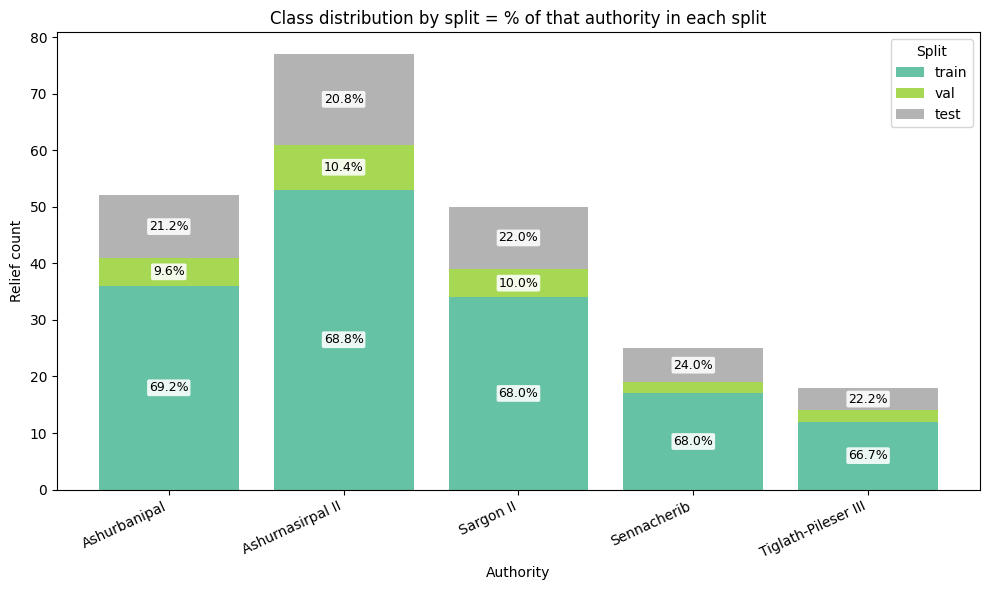

In [ ]:
relief_split_df = (
    df[["Relief_ID", "Authority", "split"]]
    .drop_duplicates(subset=["Relief_ID"])
)

dist= pd.crosstab(
    relief_split_df["Authority"],
    relief_split_df["split"]
)

print("\033[4m" + "split distribution:" + f"\033[0m\n {dist}")

split_order = ["train", "val", "test"]

pct_within_authority = dist.div(dist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
categories = dist.index.astype(str)
x = np.arange(len(categories))
colors = plt.cm.Set2(np.linspace(0, 1, len(split_order)))
bottom = np.zeros(len(categories))
max_total = dist.sum(axis=1).max()

for i, split_name in enumerate(split_order):
    heights = dist[split_name].to_numpy()
    pcts = pct_within_authority[split_name].to_numpy()
    ax.bar(x, heights, bottom=bottom, label=split_name, color=colors[i])
    for j, (h, p) in enumerate(zip(heights, pcts)):
        if h <= 0 or h < 0.04 * max_total:
            continue
        ax.text(
            x[j],
            bottom[j] + h / 2,
            f"{p:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.88, edgecolor="none"),
        )
    bottom += heights

ax.set_xticks(x, categories, rotation=25, ha="right")
ax.set_xlabel("Authority")
ax.set_ylabel("Relief count")
ax.set_title("Class distribution by split = % of that authority in each split")
ax.legend(title="Split")
fig.tight_layout()
plt.show()


# iamge level expansion

In [ ]:
records = []
unmatched_files = []
bad_format_files = []
bad_suffix_files = []

valid_suffixes = [".jpg", ".jpeg", ".png", ".tif", ".tiff"]
pattern = re.compile(r"^(?P<relief_id>.+)-(?P<view_index>\d+)\.(?P<suffix>[A-Za-z0-9]+)$")


for img_path in image_root.iterdir():
    if img_path.name == "HMA S.856.3.1-1.tif":
        print(img_path)
    if not img_path.is_file():
        continue

    suffix_lower = img_path.suffix.lower()
    if suffix_lower not in valid_suffixes:
        bad_suffix_files.append(img_path.name)
        continue


    match = pattern.match(img_path.name)
    if match is None:
        bad_format_files.append(img_path.name)
        continue

    relief_id = match.group("relief_id")
    view_index = int(match.group("view_index"))

    if relief_id not in df["Relief_ID"].values:
        unmatched_files.append(img_path.name)
        continue

    records.append({
        "Relief_ID": relief_id,
        "Authority": df[df["Relief_ID"] == relief_id]["Authority"].values[0],
        "split": df[df["Relief_ID"] == relief_id]["split"].values[0],
        "image_path": img_path,
        "view_index": view_index,
        "suffix": suffix_lower,
    })

image_df = pd.DataFrame(records)

assert not image_df.empty, "No matched image files were found."

missing_reliefs = set(df["Relief_ID"]) - set(image_df["Relief_ID"])

print(f"Matched images: {len(image_df)}")
print(f"Unique matched Relief_IDs: {image_df['Relief_ID'].nunique()}")
print(f"Reliefs with no matched local image files: {len(missing_reliefs)}")
print(f"The missing reliefs are: {missing_reliefs}")

print("\nImage-level split counts:")
print(image_df["split"].value_counts())

print("\nImage counts by class and split:")
print(pd.crosstab(image_df["split"], image_df["Authority"]))

if bad_format_files:
    print(f"\nFiles skipped due to bad filename format: {len(bad_format_files)}")
    print(bad_format_files[:20])

if unmatched_files:
    print(f"\nFiles skipped because Relief_ID not found in metadata: {len(unmatched_files)}")
    print(unmatched_files[:20])

if bad_suffix_files:
    print(f"\nFiles skipped due to unsupported suffix: {len(bad_suffix_files)}")
    print(bad_suffix_files[:20])

image_df = image_df.sort_values(["Relief_ID", "view_index"]).reset_index(drop=True)



/mnt/c/Users/chend/Desktop/My_Files/Thesis/Dataset/dataset_v2/HMA S.856.3.1-1.tif
Matched images: 734
Unique matched Relief_IDs: 222
Reliefs with no matched local image files: 0
The missing reliefs are: set()

Image-level split counts:
split
train    505
val      115
test     114
Name: count, dtype: int64

Image counts by class and split:
Authority  Ashurbanipal  Ashurnasirpal II  Sargon II  Sennacherib  \
split                                                               
test                 31                38         25            4   
train               184               173         83           41   
val                  52                26         21            6   

Authority  Tiglath-Pileser III  
split                           
test                        16  
train                       24  
val                         10  

Files skipped because Relief_ID not found in metadata: 38
['AO 19880-1.jpg', 'AO 19889-1.jpg', 'AO 19889-10.jpg', 'AO 19889-11.jpg', 'AO 19889-2.jp

In [ ]:
output_image_table =_repo_root()/config["data"]["csv_path"]
image_df.to_csv(output_image_table, index=False)
print(f"\nSaved image-level dataset table to: {output_image_table}")


Saved image-level dataset table to: /home/kostya/projects/thesis-assyrian-relief/data/splits/image_level_dataset_v2.csv
